In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

In [5]:
import pandas as pd

data = pd.read_csv("HomeC.xls")

data.columns = data.columns.str.strip()

print("Dataset loaded successfully")
print("Shape:", data.shape)

data.head()

Dataset loaded successfully
Shape: (108793, 32)


C:\Users\DELL\AppData\Local\Temp\ipykernel_13412\1926119625.py:3: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("HomeC.xls")


,time,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
0,1451624400,0.932833,0.003483,0.932833,0.000033,0.020700,0.061917,0.442633,0.124150,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1,1451624401,0.934333,0.003467,0.934333,0.000000,0.020717,0.063817,0.444067,0.124000,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2,1451624402,0.931817,0.003467,0.931817,0.000017,0.020700,0.062317,0.446067,0.123533,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
3,1451624403,1.022050,0.003483,1.022050,0.000017,0.106900,0.068517,0.446583,0.123133,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
4,1451624404,1.139400,0.003467,1.139400,0.000133,0.236933,0.063983,0.446533,0.122850,0.006850,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0


In [8]:
print("Column Names:")
print(data.columns)

Column Names:
Index(['time', 'use [kW]', 'gen [kW]', 'House overall [kW]', 'Dishwasher [kW]',
       'Furnace 1 [kW]', 'Furnace 2 [kW]', 'Home office [kW]', 'Fridge [kW]',
       'Wine cellar [kW]', 'Garage door [kW]', 'Kitchen 12 [kW]',
       'Kitchen 14 [kW]', 'Kitchen 38 [kW]', 'Barn [kW]', 'Well [kW]',
       'Microwave [kW]', 'Living room [kW]', 'Solar [kW]', 'temperature',
       'icon', 'humidity', 'visibility', 'summary', 'apparentTemperature',
       'pressure', 'windSpeed', 'cloudCover', 'windBearing', 'precipIntensity',
       'dewPoint', 'precipProbability'],
      dtype='object')


In [10]:
print("Dataset information:")
data.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108793 entries, 0 to 108792
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   time                 108793 non-null  int64  
 1   use [kW]             108793 non-null  float64
 2   gen [kW]             108793 non-null  float64
 3   House overall [kW]   108793 non-null  float64
 4   Dishwasher [kW]      108793 non-null  float64
 5   Furnace 1 [kW]       108793 non-null  float64
 6   Furnace 2 [kW]       108793 non-null  float64
 7   Home office [kW]     108793 non-null  float64
 8   Fridge [kW]          108793 non-null  float64
 9   Wine cellar [kW]     108792 non-null  float64
 10  Garage door [kW]     108792 non-null  float64
 11  Kitchen 12 [kW]      108792 non-null  float64
 12  Kitchen 14 [kW]      108792 non-null  float64
 13  Kitchen 38 [kW]      108792 non-null  float64
 14  Barn [kW]            108792 non-null  float64
 

In [15]:
print("Checking missing values in the dataset")

missing_values = data.isnull().sum()

print(missing_values)

Checking missing values in the dataset
use [kW]               0
gen [kW]               0
House overall [kW]     0
Dishwasher [kW]        0
Furnace 1 [kW]         0
Furnace 2 [kW]         0
Home office [kW]       0
Fridge [kW]            0
Wine cellar [kW]       0
Garage door [kW]       0
Kitchen 12 [kW]        0
Kitchen 14 [kW]        0
Kitchen 38 [kW]        0
Barn [kW]              0
Well [kW]              0
Microwave [kW]         0
Living room [kW]       0
Solar [kW]             0
temperature            0
icon                   1
humidity               0
visibility             0
summary                1
apparentTemperature    0
pressure               0
windSpeed              0
cloudCover             1
windBearing            0
precipIntensity        0
dewPoint               0
precipProbability      0
dtype: int64


In [16]:
# Fill missing numeric values with mean
data = data.fillna(data.mean(numeric_only=True))

print("Missing values have been handled successfully")

Missing values have been handled successfully


In [23]:

data = data.reset_index()

data["time"] = pd.to_datetime(data["time"], errors="coerce")

print("Time column converted successfully")

Time column converted successfully


In [24]:

data.set_index("time", inplace=True)

print("Time column set as index")

Time column set as index


In [25]:
data.columns = data.columns.str.strip()

data = data.reset_index()

data["time"] = pd.to_datetime(data["time"], errors="coerce")

data.set_index("time", inplace=True)

print("Time column converted and indexed successfully")

Time column converted and indexed successfully


In [28]:

numeric_data = data.select_dtypes(include=["number"])

hourly_data = numeric_data.resample("h").mean()

print("Hourly energy consumption data created")

hourly_data.head()

Hourly energy consumption data created


,index,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],...,temperature,humidity,visibility,apparentTemperature,pressure,windSpeed,windBearing,precipIntensity,dewPoint,precipProbability
time,,,,,,,,,,,,,,,,,,,,,
1970-01-01,54396.0,0.956471,0.066935,0.956471,0.033798,0.192918,0.221994,0.078773,0.053771,0.020883,...,32.241536,0.618106,9.261053,26.442571,1015.549263,7.697786,211.146978,0.002676,19.763517,0.056085


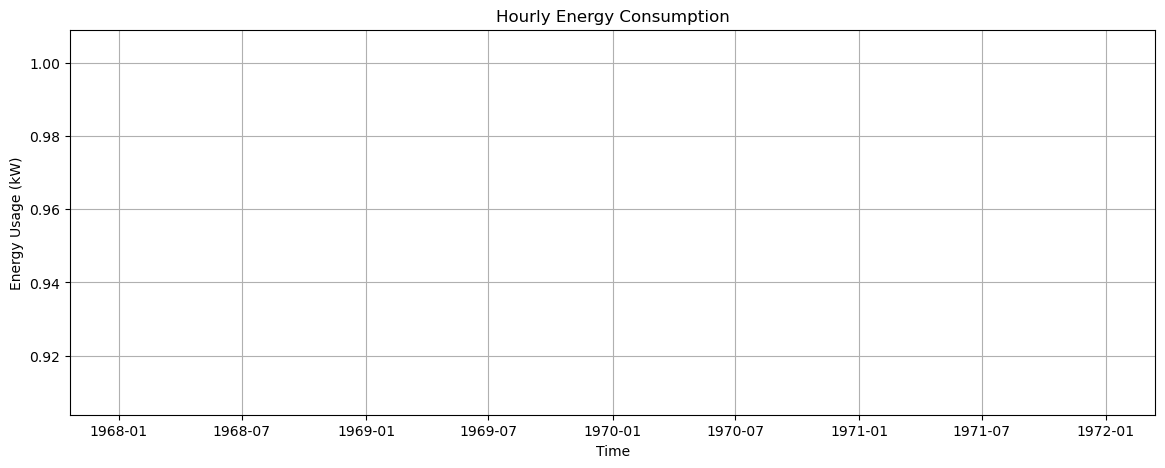

In [33]:
plt.figure(figsize=(14,5))

plt.plot(hourly_data.index, hourly_data["House overall [kW]"])

plt.title("Hourly Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Energy Usage (kW)")

plt.grid(True)

plt.show()

In [34]:
print("Final processed dataset shape:", hourly_data.shape)

hourly_data.describe()

Final processed dataset shape: (1, 29)


,index,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],...,temperature,humidity,visibility,apparentTemperature,pressure,windSpeed,windBearing,precipIntensity,dewPoint,precipProbability
count,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
mean,54396.0,0.956471,0.066935,0.956471,0.033798,0.192918,0.221994,0.078773,0.053771,0.020883,...,32.241536,0.618106,9.261053,26.442571,1015.549263,7.697786,211.146978,0.002676,19.763517,0.056085
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,54396.0,0.956471,0.066935,0.956471,0.033798,0.192918,0.221994,0.078773,0.053771,0.020883,...,32.241536,0.618106,9.261053,26.442571,1015.549263,7.697786,211.146978,0.002676,19.763517,0.056085
25%,54396.0,0.956471,0.066935,0.956471,0.033798,0.192918,0.221994,0.078773,0.053771,0.020883,...,32.241536,0.618106,9.261053,26.442571,1015.549263,7.697786,211.146978,0.002676,19.763517,0.056085
50%,54396.0,0.956471,0.066935,0.956471,0.033798,0.192918,0.221994,0.078773,0.053771,0.020883,...,32.241536,0.618106,9.261053,26.442571,1015.549263,7.697786,211.146978,0.002676,19.763517,0.056085
75%,54396.0,0.956471,0.066935,0.956471,0.033798,0.192918,0.221994,0.078773,0.053771,0.020883,...,32.241536,0.618106,9.261053,26.442571,1015.549263,7.697786,211.146978,0.002676,19.763517,0.056085
max,54396.0,0.956471,0.066935,0.956471,0.033798,0.192918,0.221994,0.078773,0.053771,0.020883,...,32.241536,0.618106,9.261053,26.442571,1015.549263,7.697786,211.146978,0.002676,19.763517,0.056085
